# 07 Inferens med StatsModels

Bruker variablene valgt i 06 (via CV + magefølelse) og kjører GLM/WLS i statsmodels for å få:
- Koeffisienter
- Standardfeil
- P-verdier
- Konfidensintervaller

**Merk:** Vi dropper Ridge-regularisering for inferens (alpha=0)

In [17]:
### Unngå time-outing ved oppstart
print("hello world")

hello world


In [18]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

sns.set_theme(style="whitegrid")

project_root = Path.cwd().resolve().parent.parent
code_dir = project_root / "code"
if str(code_dir) not in sys.path:
    sys.path.append(str(code_dir))

from utils.data_load import load_raw_data
from utils.data_prep import data_prep
from utils.models import (
    build_count_model,
    build_mean_duration_model,
    DEFAULT_CATEGORICAL_FEATURES,
)

In [19]:
# Konfig (samme som 06)
COUNT_TARGET = "antall_samtaler"
DURATION_TARGET = "behandlingstid_snitt"
WEIGHT_COL = "antall_samtaler"

POISSON_ALPHA = 0.0  # Ingen regularisering for inferens
POISSON_MAX_ITER = 10000

NEWSLETTER_CSV = project_root / "data" / "newsletter_sendouts.csv"
WEATHER_CSV = project_root / "data" / "oslo_weather.csv"

# Fra 06: variabler valgt med CV 
count_feature_cols = [
    "maaned",
    "stddev_premieendring_b30_for",
    "antall_hf_f30_tot",
    "stddev_premieendring_f30_for",
    "snitt_premieendring_f30_for",
    "er_dag_foer_helligdag",
    "ukedag",
]

duration_feature_cols = [
    "antall_nye_kunder_b30_tot",
    "maaned",
    "stddev_premieendring_b30_for",
    "snitt_premieendring_b30_for",
    "snitt_premieendring_f30_for",
]

print("Count features:", count_feature_cols)
print("Duration features:", duration_feature_cols)

Count features: ['maaned', 'stddev_premieendring_b30_for', 'antall_hf_f30_tot', 'stddev_premieendring_f30_for', 'snitt_premieendring_f30_for', 'er_dag_foer_helligdag', 'ukedag']
Duration features: ['antall_nye_kunder_b30_tot', 'maaned', 'stddev_premieendring_b30_for', 'snitt_premieendring_b30_for', 'snitt_premieendring_f30_for']


In [20]:
# Last data
df_inngang, df_info, df_weather = load_raw_data(
    session=None,
    weather_path=WEATHER_CSV,
)

df = data_prep(
    df_inngang=df_inngang,
    df_info=df_info,
    df_weather=df_weather,
    cols_to_remove=None,
    newsletter_dates_csv=str(NEWSLETTER_CSV),
)

print("Data shape:", df.shape)
print("Periode:", df["ankomst_dato"].min(), "->", df["ankomst_dato"].max())

Data shape: (499, 140)
Periode: 2024-06-03 -> 2026-06-02


In [21]:
# Valider og forbered frames
count_missing = [c for c in count_feature_cols if c not in df.columns]
duration_missing = [c for c in duration_feature_cols if c not in df.columns]

if count_missing:
    print("Count-features mangler:", count_missing)
if duration_missing:
    print("Duration-features mangler:", duration_missing)

count_feature_cols = [c for c in count_feature_cols if c in df.columns]
duration_feature_cols = [c for c in duration_feature_cols if c in df.columns]

if len(count_feature_cols) == 0:
    raise ValueError("count_feature_cols er tom etter validering")
if len(duration_feature_cols) == 0:
    raise ValueError("duration_feature_cols er tom etter validering")

cat_count = [c for c in DEFAULT_CATEGORICAL_FEATURES if c in count_feature_cols]
cat_duration = [c for c in DEFAULT_CATEGORICAL_FEATURES if c in duration_feature_cols]

# Frames med dropna
count_cols = list(dict.fromkeys(count_feature_cols + [COUNT_TARGET]))
duration_cols = list(dict.fromkeys(duration_feature_cols + [DURATION_TARGET, WEIGHT_COL]))

count_frame = df[count_cols].dropna().copy()
duration_frame = df[duration_cols].dropna().copy()

print("Count frame:", count_frame.shape)
print("Duration frame:", duration_frame.shape)

Count frame: (455, 8)
Duration frame: (455, 7)


## COUNT MODEL - Poisson GLM

Bruker sklearn-pipeline for preprocessing (StandardScaler + OneHotEncoder), deretter sender transformert data til statsmodels GLM.

In [22]:
# 1) Bygn sklearn-model kun for preprocessing (alpha=0)
X_count = count_frame[count_feature_cols]

sklearn_count_model = build_count_model(
    X_count,
    categorical_features=cat_count,
    alpha=POISSON_ALPHA,
    max_iter=POISSON_MAX_ITER,
)

# 2) Trekk ut preprocessoren
preprocessor = sklearn_count_model.named_steps["prep"]

# 3) Transform data
X_count_transformed = preprocessor.fit_transform(X_count)

# 4) Hent feature-navn og gjør til tett matrise
feature_names = preprocessor.get_feature_names_out()
if hasattr(X_count_transformed, "toarray"):
    X_count_transformed = X_count_transformed.toarray()

# 5) DataFrame for statsmodels
X_count_sm = pd.DataFrame(X_count_transformed, columns=feature_names, index=X_count.index)
X_count_sm = sm.add_constant(X_count_sm)

print("Transformed shape:", X_count_sm.shape)
print("Feature count:", len(feature_names))

Transformed shape: (455, 24)
Feature count: 23


In [23]:
# Fit Poisson GLM
y_count = count_frame[COUNT_TARGET].astype(float).values

glm_count = sm.GLM(
    y_count,
    X_count_sm,
    family=sm.families.NegativeBinomial(),
)

result_count = glm_count.fit()
print(result_count.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                  455
Model:                            GLM   Df Residuals:                      434
Model Family:        NegativeBinomial   Df Model:                           20
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -3062.5
Date:                Fri, 10 Jul 2026   Deviance:                       36.504
Time:                        10:22:33   Pearson chi2:                     30.9
No. Iterations:                     6   Pseudo R-squ. (CS):            0.04994
Covariance Type:            nonrobust                                         
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
const 

c:\Users\ra5\Workspaces\inngangsanalyse\.venv\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


In [24]:
# Sjekk overdispersion (Poisson antar Var=E)
pearson_chi2 = result_count.pearson_chi2
df_resid = result_count.df_resid
disp_param = pearson_chi2 / df_resid

print(f"Pearson chi-squared: {pearson_chi2:.2f}")
print(f"DF residual: {df_resid}")
print(f"Dispersion parameter: {disp_param:.4f}")
print()
if disp_param > 1.5:
    print("ADVARSEL: Overdispersion detektert (disp > 1.5)")
    print("   Vurder robust standardfeil: result.get_robustcov_results()")
else:
    print("OK: Akseptabel dispersjon (nær 1)")

Pearson chi-squared: 30.87
DF residual: 434
Dispersion parameter: 0.0711

OK: Akseptabel dispersjon (nær 1)


In [25]:
# Ekstrahér og presenter koeffisienter med rate-ratio
coef_df = pd.DataFrame({
    "Koeffisient": result_count.params,
    "Std Err": result_count.bse,
    "Z-stat": result_count.tvalues,
    "P-verdi": result_count.pvalues,
    "[0.025": result_count.conf_int()[0],
    "0.975]": result_count.conf_int()[1],
})

# Rate ratio: exp(koef)
coef_df["Rate Ratio (exp(coef))"] = np.exp(coef_df["Koeffisient"])

# Sorter etter p-verdi
coef_df = coef_df.sort_values("P-verdi")

print("\nKoeffisienter (sortert etter signifikans):")
print(coef_df.to_string())

print("\n" + "="*80)
print("TOLKING:")
print("="*80)
print("Koeffisient: Effekt på log-skala (linjer estimert med StandardScaler)")
print("Rate Ratio: exp(coef) = multiplikator på antall samtaler")
print("  Eksempel: RR=1.30 → 30% økning per 1 std enhet økning i variabelen")
print("  Eksempel: RR=0.85 → 15% nedgang per 1 std enhet økning i variabelen")
print("P-verdi < 0.05: Signifikant på 5% nivå (markert med ***)")


Koeffisienter (sortert etter signifikans):
                                   Koeffisient   Std Err    Z-stat   P-verdi    [0.025    0.975]  Rate Ratio (exp(coef))
cat__er_dag_foer_helligdag_0          2.414971  0.831066  2.905872  0.003662  0.786112  4.043830               11.189444
cat__ukedag_2                         0.971987  0.339801  2.860457  0.004230  0.305989  1.637985                2.643191
const                                 4.520811  1.640518  2.755721  0.005856  1.305454  7.736168               91.910123
cat__ukedag_3                         0.927688  0.343362  2.701775  0.006897  0.254710  1.600665                2.528655
cat__ukedag_1                         0.887341  0.337095  2.632315  0.008481  0.226647  1.548036                2.428664
cat__ukedag_4                         0.893032  0.344844  2.589668  0.009607  0.217150  1.568915                2.442525
cat__er_dag_foer_helligdag_1          2.105840  0.847202  2.485642  0.012932  0.445355  3.766325             

## DURATION MODEL - Weighted Linear Regression (WLS)

Bruker samme preprocessing, men fit OLS/WLS uten regularisering for inferens.

In [26]:
# 1) Bygn sklearn-model kun for preprocessing
X_duration = duration_frame[duration_feature_cols]

sklearn_duration_model = build_mean_duration_model(
    X_duration,
    categorical_features=cat_duration,
    alpha=1.0,  # Spiller ingen rolle siden vi kun bruker preprocessing
)

# 2) Trekk ut preprocessoren
preprocessor_d = sklearn_duration_model.named_steps["prep"]

# 3) Transform data
X_duration_transformed = preprocessor_d.fit_transform(X_duration)

# 4) Hent feature-navn og gjør til tett matrise
feature_names_d = preprocessor_d.get_feature_names_out()
if hasattr(X_duration_transformed, "toarray"):
    X_duration_transformed = X_duration_transformed.toarray()

# 5) DataFrame for statsmodels
X_duration_sm = pd.DataFrame(X_duration_transformed, columns=feature_names_d, index=X_duration.index)
X_duration_sm = sm.add_constant(X_duration_sm)

print("Transformed shape:", X_duration_sm.shape)
print("Feature count:", len(feature_names_d))

Transformed shape: (455, 17)
Feature count: 16


In [27]:
# Fit WLS med vekter = antall samtaler
y_duration = duration_frame[DURATION_TARGET].astype(float).values
weights = duration_frame[WEIGHT_COL].astype(float).values

wls_duration = sm.WLS(
    y_duration,
    X_duration_sm,
    weights=weights,
)

result_duration = wls_duration.fit()
print(result_duration.summary())

                            WLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.281
Model:                            WLS   Adj. R-squared:                  0.256
Method:                 Least Squares   F-statistic:                     11.44
Date:                Fri, 10 Jul 2026   Prob (F-statistic):           1.00e-23
Time:                        10:22:33   Log-Likelihood:                -2177.2
No. Observations:                 455   AIC:                             4386.
Df Residuals:                     439   BIC:                             4452.
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
const 

In [28]:
# Ekstrahér og presenter koeffisienter
coef_df_d = pd.DataFrame({
    "Koeffisient": result_duration.params,
    "Std Err": result_duration.bse,
    "T-stat": result_duration.tvalues,
    "P-verdi": result_duration.pvalues,
    "[0.025": result_duration.conf_int()[0],
    "0.975]": result_duration.conf_int()[1],
})

# Sorter etter p-verdi
coef_df_d = coef_df_d.sort_values("P-verdi")

print("\nKoeffisienter (sortert etter signifikans):")
print(coef_df_d.to_string())

print("\n" + "="*80)
print("TOLKING:")
print("="*80)
print("Koeffisient: Effekt på behandlingstid (sekunder eller samme enhet som target)")
print("           Per 1 standardavvik økning i variabelen (grunnet StandardScaler)")
print("P-verdi < 0.05: Signifikant på 5% nivå")
print("R-squared:", f"{result_duration.rsquared:.4f}")
print("Adj R-squared:", f"{result_duration.rsquared_adj:.4f}")


Koeffisienter (sortert etter signifikans):
                                   Koeffisient     Std Err    T-stat   P-verdi      [0.025      0.975]
num__antall_nye_kunder_b30_tot       19.236407    4.443178  4.329425  0.000019   10.503863   27.968952
num__stddev_premieendring_b30_for     6.207466    1.602145  3.874472  0.000123    3.058638    9.356293
num__snitt_premieendring_f30_for     14.701541    4.076129  3.606741  0.000346    6.690388   22.712694
num__snitt_premieendring_b30_for    -10.929192    3.545882 -3.082221  0.002184  -17.898206   -3.960178
cat__maaned_1                        24.065238   11.839042  2.032701  0.042684    0.796992   47.333484
cat__maaned_8                        12.591342    8.097330  1.554999  0.120667   -3.323008   28.505692
cat__maaned_9                        13.312141    8.593498  1.549095  0.122080   -3.577369   30.201652
cat__maaned_10                       18.082572   11.815841  1.530367  0.126646   -5.140075   41.305220
cat__maaned_3                

## SAMMENLIGNING: Signifikante Variabler

Oversikt over hvilke variabler som er signifikante (p < 0.05) i hver modell.

In [29]:
# Count: signifikante variabler
sig_count = coef_df[coef_df["P-verdi"] < 0.05]
print("ANTALL SAMTALER - Signifikante variabler (p < 0.05):")
print("="*80)
if len(sig_count) > 0:
    for idx, row in sig_count.iterrows():
        rr = row["Rate Ratio (exp(coef))"]
        effect = f"+{(rr-1)*100:.1f}%" if rr > 1 else f"{(rr-1)*100:.1f}%"
        print(f"{idx:45s} | RR={rr:6.3f} ({effect:>7s}) | p={row['P-verdi']:.4f}")
else:
    print("Ingen signifikante variabler")

print("\n")
print("BEHANDLINGSTID - Signifikante variabler (p < 0.05):")
print("="*80)
sig_duration = coef_df_d[coef_df_d["P-verdi"] < 0.05]
if len(sig_duration) > 0:
    for idx, row in sig_duration.iterrows():
        coef = row["Koeffisient"]
        direction = "+" if coef > 0 else ""
        print(f"{idx:45s} | Effekt={direction}{coef:7.3f} | p={row['P-verdi']:.4f}")
else:
    print("Ingen signifikante variabler")

ANTALL SAMTALER - Signifikante variabler (p < 0.05):
cat__er_dag_foer_helligdag_0                  | RR=11.189 (+1018.9%) | p=0.0037
cat__ukedag_2                                 | RR= 2.643 (+164.3%) | p=0.0042
const                                         | RR=91.910 (+9091.0%) | p=0.0059
cat__ukedag_3                                 | RR= 2.529 (+152.9%) | p=0.0069
cat__ukedag_1                                 | RR= 2.429 (+142.9%) | p=0.0085
cat__ukedag_4                                 | RR= 2.443 (+144.3%) | p=0.0096
cat__er_dag_foer_helligdag_1                  | RR= 8.214 (+721.4%) | p=0.0129
cat__ukedag_5                                 | RR= 2.318 (+131.8%) | p=0.0140
cat__maaned_5                                 | RR= 1.691 ( +69.1%) | p=0.0164
cat__maaned_8                                 | RR= 1.627 ( +62.7%) | p=0.0212
cat__maaned_3                                 | RR= 1.598 ( +59.8%) | p=0.0228
cat__maaned_6                                 | RR= 1.495 ( +49.5%) | p=0.03

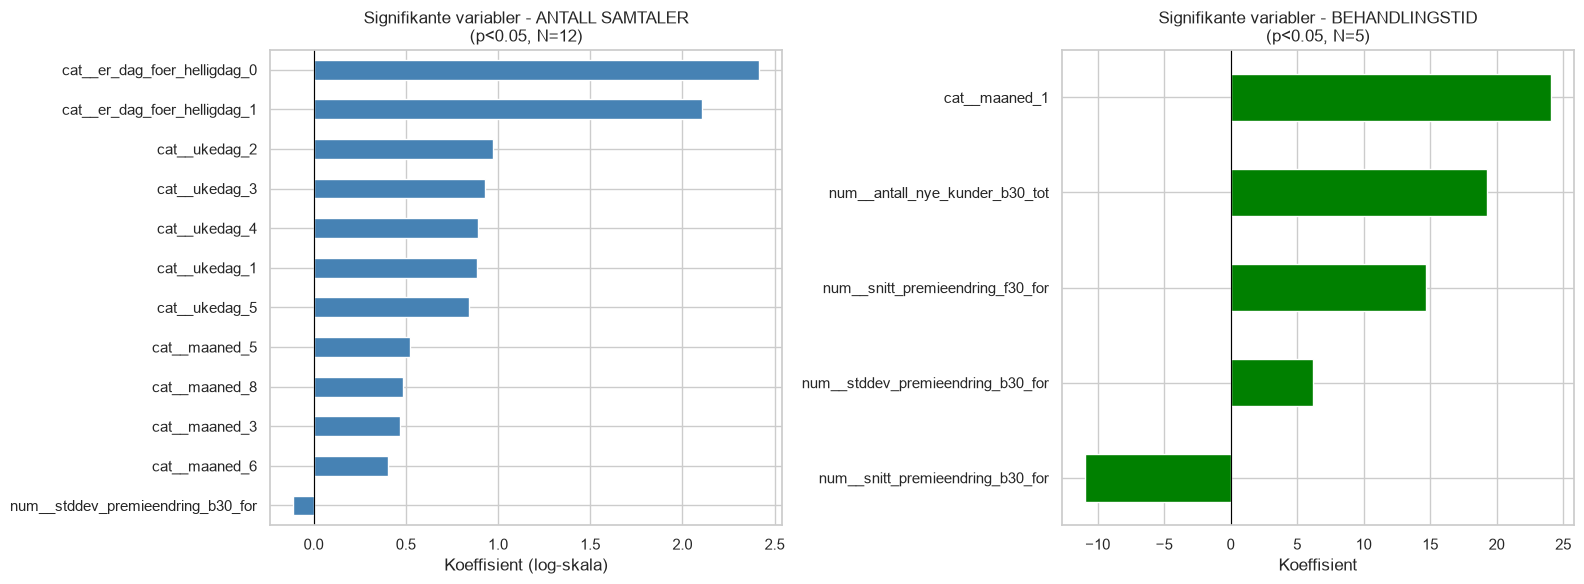

In [30]:
# Visualiser signifikante koeffisienter
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Count-modellen
sig_c = coef_df[coef_df["P-verdi"] < 0.05].drop("const", errors="ignore")
if len(sig_c) > 0:
    sig_c["Koeffisient"].sort_values().plot(kind="barh", ax=axes[0], color="steelblue")
    axes[0].axvline(0, color="black", linestyle="-", linewidth=0.8)
    axes[0].set_xlabel("Koeffisient (log-skala)")
    axes[0].set_title(f"Signifikante variabler - ANTALL SAMTALER\n(p<0.05, N={len(sig_c)})")
else:
    axes[0].text(0.5, 0.5, "Ingen signifikante variabler", ha="center", va="center")
    axes[0].set_title("Signifikante variabler - ANTALL SAMTALER")

# Duration-modellen
sig_d = coef_df_d[coef_df_d["P-verdi"] < 0.05].drop("const", errors="ignore")
if len(sig_d) > 0:
    sig_d["Koeffisient"].sort_values().plot(kind="barh", ax=axes[1], color="green")
    axes[1].axvline(0, color="black", linestyle="-", linewidth=0.8)
    axes[1].set_xlabel("Koeffisient")
    axes[1].set_title(f"Signifikante variabler - BEHANDLINGSTID\n(p<0.05, N={len(sig_d)})")
else:
    axes[1].text(0.5, 0.5, "Ingen signifikante variabler", ha="center", va="center")
    axes[1].set_title("Signifikante variabler - BEHANDLINGSTID")

plt.tight_layout()
plt.show()